In [14]:
import pandas as pd
import numpy as np
%matplotlib inline

In [15]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.drop(columns=['customerID'], inplace=True)
data['TotalCharges'] = data['TotalCharges'].apply(pd.to_numeric,errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())


In [16]:
# 1. Average monthly spend
data['avg_monthly_spend'] = data['TotalCharges'] / (data['tenure'] + 1)

# 2. Is new customer
data['is_new_customer'] = (data['tenure'] < 12).astype(int)

# 3. Has support services
data['has_support_services'] = (
    (data['OnlineSecurity'] == 'Yes').astype(int) +
    (data['TechSupport'] == 'Yes').astype(int)
)

# 4. Is high value
data['is_high_value'] = (
    data['MonthlyCharges'] > data['MonthlyCharges'].median()
).astype(int)

print("New features added ✅")
print(data[['avg_monthly_spend','is_new_customer',
            'has_support_services','is_high_value']].head())

New features added ✅
   avg_monthly_spend  is_new_customer  has_support_services  is_high_value
0          14.925000                1                     0              0
1          53.985714                0                     1              0
2          36.050000                1                     1              0
3          40.016304                0                     2              0
4          50.550000                1                     0              1


---
# EDA

In [17]:
# ── 1. Load & clean ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#3498db', '#e74c3c']

# Prepare a clean copy for EDA
df = data.copy()

# Step 1: Convert first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Fill NaN AFTER conversion (now it's float64)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(df['TotalCharges'].isna().sum())

0


### Churn Distribution

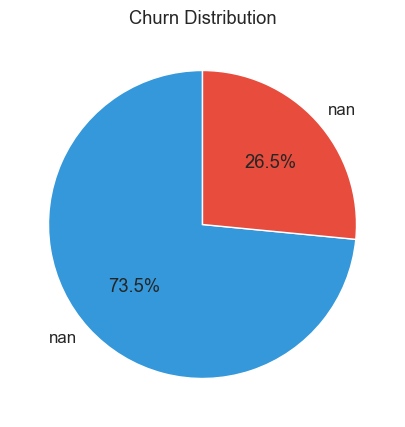

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['Churn'].value_counts().sort_index()
labels = counts.index.map({0:'No',1:'Yes'})

ax.pie(
    counts,
    labels=counts.index.map({0: 'No', 1: 'Yes'}),
    autopct='%1.1f%%',
    startangle=90,
    colors=PALETTE
)
ax.set_title('Churn Distribution')
plt.show()

### Numerical Features

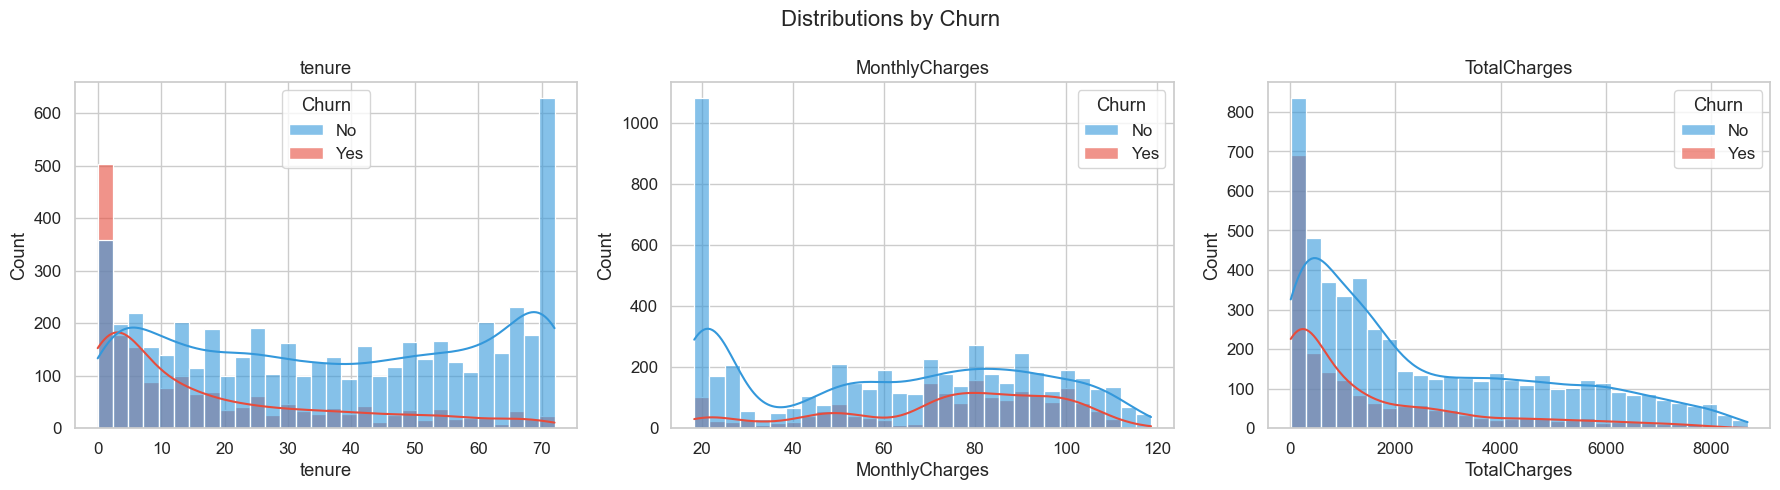

In [19]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions by Churn', fontsize=16)
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette=PALETTE, ax=axes[i], alpha=0.6, bins=30)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

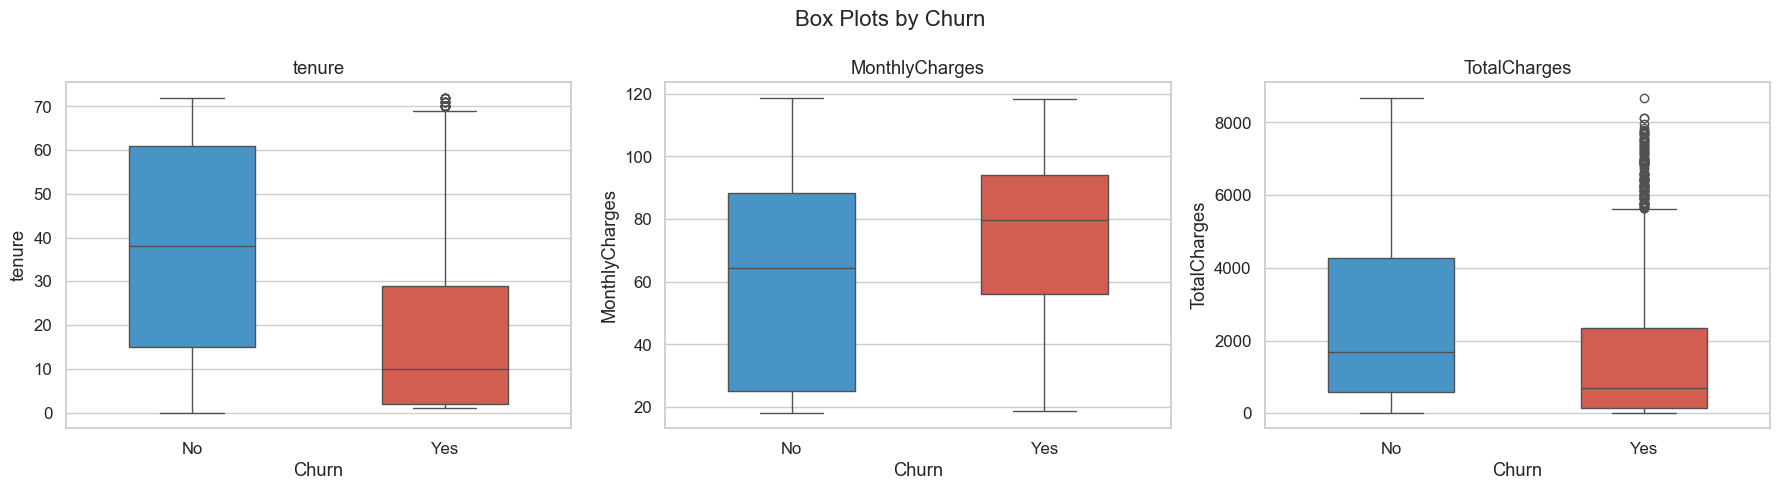

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Box Plots by Churn', fontsize=16)
for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, palette=PALETTE,
                ax=axes[i], width=0.5)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

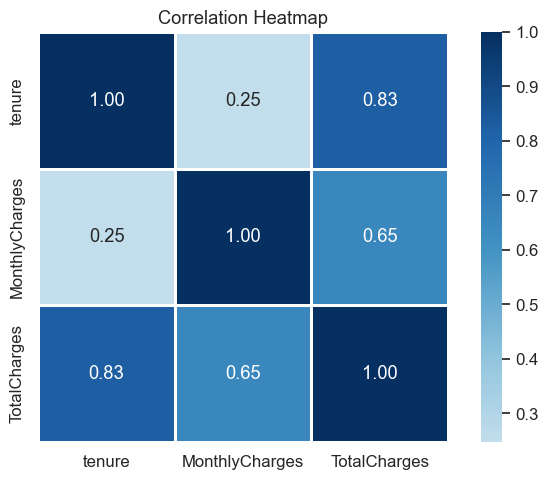

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,      # show the actual numbers inside each cell
    cmap='RdBu',    # red = positive, blue = negative correlation
    center=0,        # white = zero correlation (neutral midpoint)
    fmt='.2f',       # format numbers to 2 decimal places
    linewidths=2,    # grid lines between cells
    square=True      # force cells to be square shaped
)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Churn Rate by Category

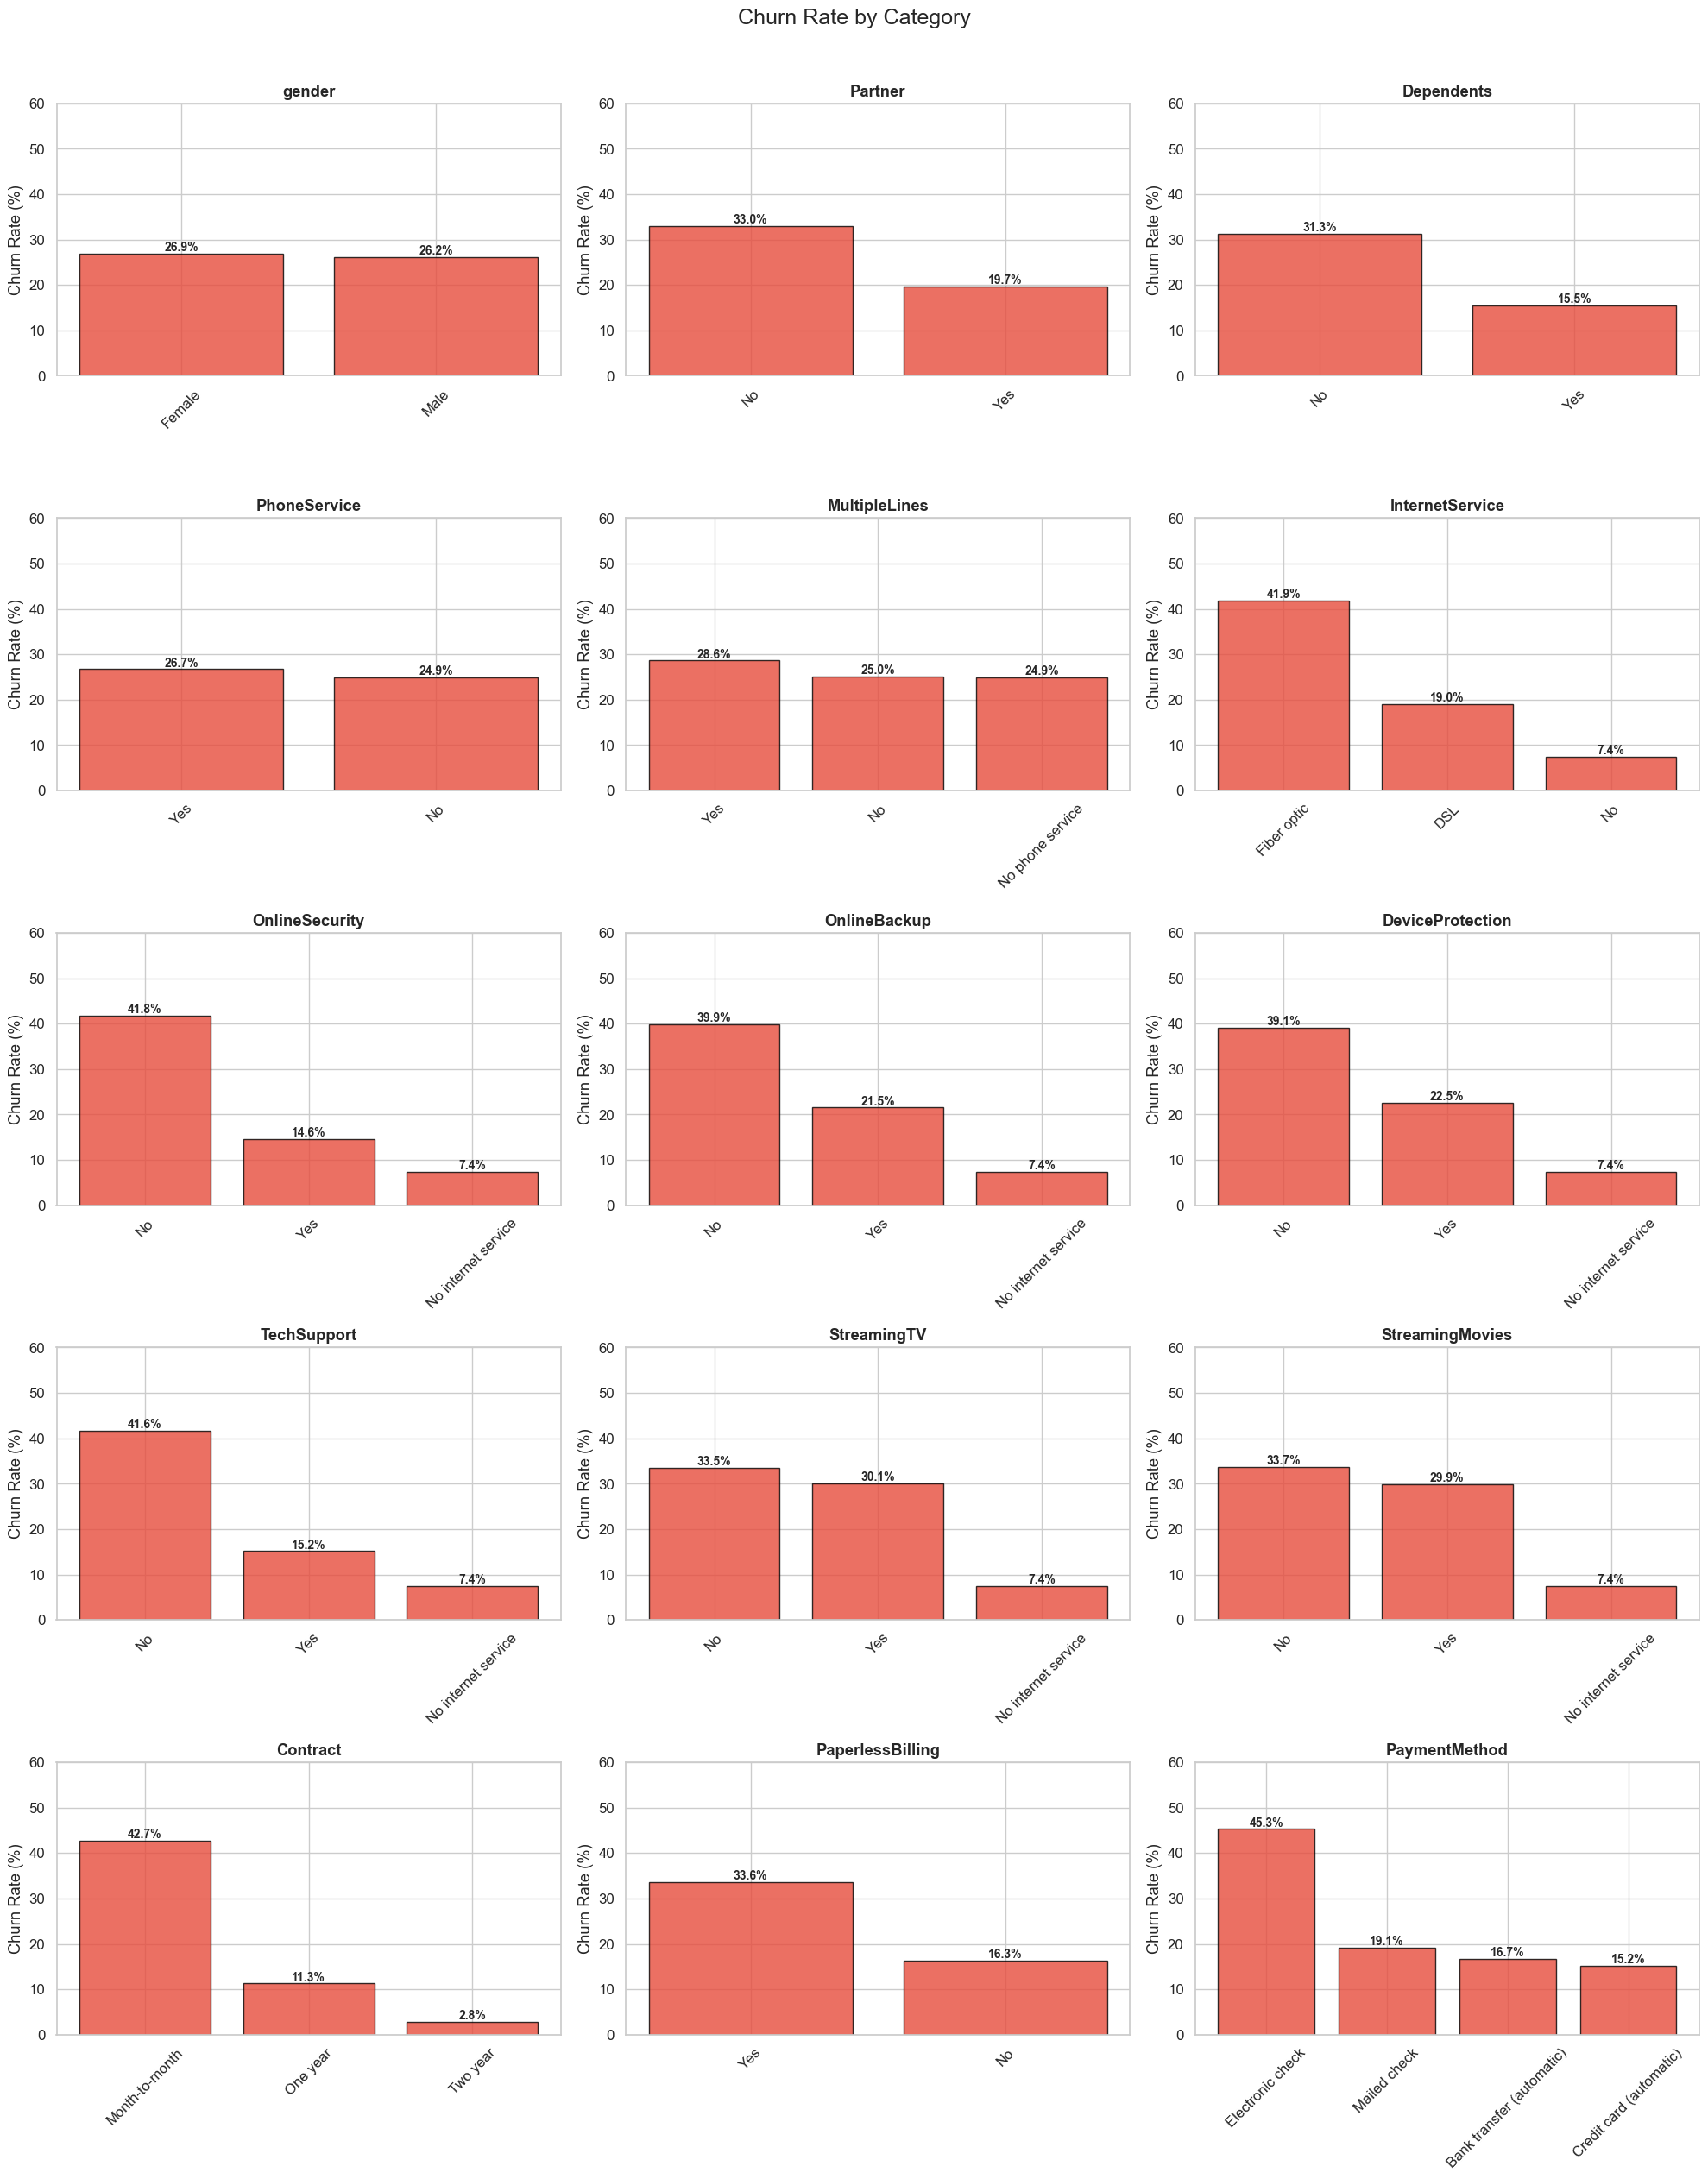

In [22]:

cat_cols = [c for c in df.select_dtypes('object').columns if c != 'Churn']

#calculates no of rows required for all plots
rows = (len(cat_cols) + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(20, 5 * rows))
fig.suptitle('Churn Rate by Category', fontsize=18, y=1.01)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    rate = rate.sort_values(ascending=False)
    bars = axes[i].bar(rate.index, rate.values, color='#e74c3c',
                       edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 60)
    axes[i].tick_params(axis='x', rotation=45)
    
    for bar in bars:
        h = bar.get_height()
        axes[i].annotate(f'{h:.1f}%',
                         xy=(bar.get_x() + bar.get_width() / 2, h),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

### Churn by Tenure Group

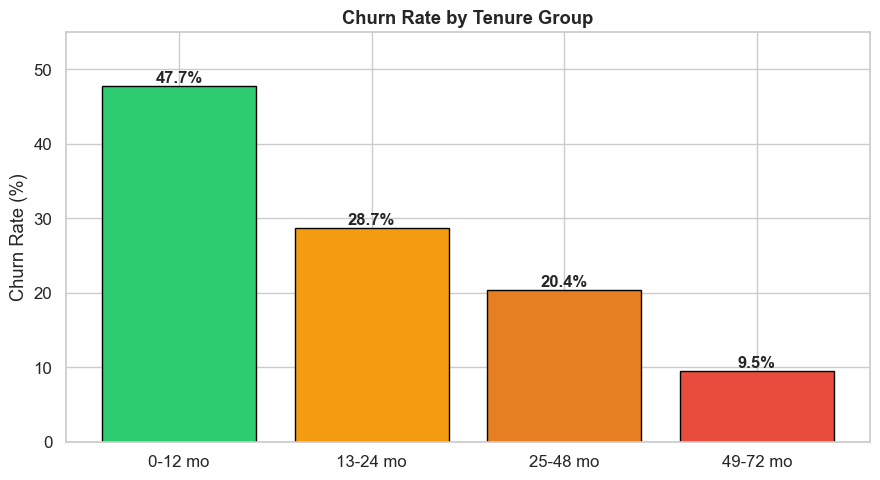

In [23]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                            labels=['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo'])

fig, ax = plt.subplots(figsize=(9, 5))
churn_tenure = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
bars = ax.bar(churn_tenure.index, churn_tenure.values,
              color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'], edgecolor='black')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
            f'{h:.1f}%', ha='center', fontweight='bold', fontsize=12)
            
ax.set_title('Churn Rate by Tenure Group', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

df.drop(columns=['tenure_group'], inplace=True)

### Monthly vs Total Charges

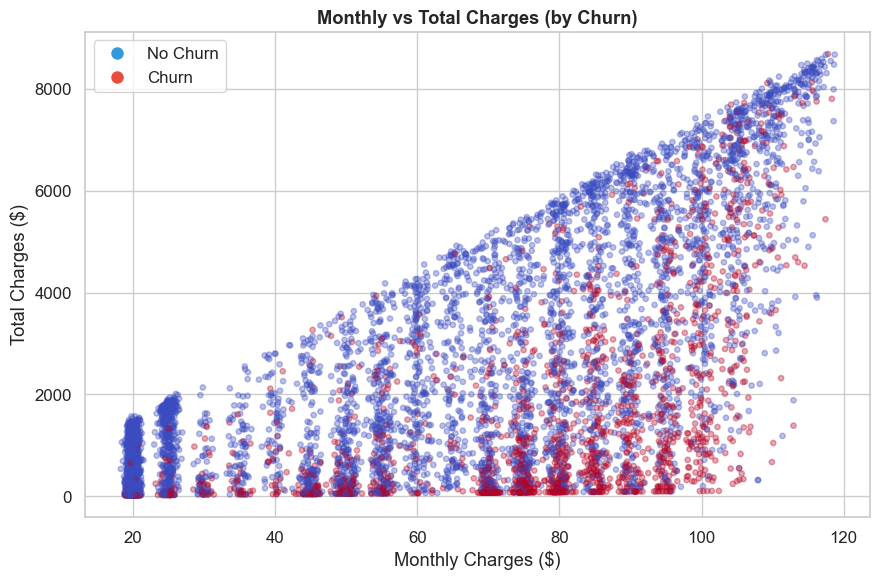

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['MonthlyCharges'], df['TotalCharges'],
           c=df['Churn'].map({'No': 0, 'Yes': 1}),
           cmap='coolwarm', alpha=0.35, s=15)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Total Charges ($)')
ax.set_title('Monthly vs Total Charges (by Churn)', fontweight='bold')
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=c, markersize=10, label=l)
                   for c, l in zip(['#3498db', '#e74c3c'], ['No Churn', 'Churn'])]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

---
# Preprocessing

In [27]:
cols_to_exclude = ["Churn", "SeniorCitizen"]

binary_cols = [
    col
    for col in data.select_dtypes(include="O").columns
    if data[col].nunique() == 2 and col not in cols_to_exclude
]
binary_cols = binary_cols + [
    "SeniorCitizen",
    "is_new_customer",
    "is_high_value",
    "has_support_services",
]  # add SeniorCitizen back ✅

multi_cat = [
    col for col in data.select_dtypes(include="O").columns if data[col].nunique() > 2
]

numerical_cols = [
    col
    for col in data.select_dtypes(include=["int64", "float64"]).columns
    if col
    not in cols_to_exclude
    + ["is_new_customer", "is_high_value", "has_support_services"]
]


print("Numerical:", numerical_cols)
print("Binary:", binary_cols)
print("Multi-cat:", multi_cat)

# Sanity check
X = data.drop(columns=["Churn"])
assert len(numerical_cols + binary_cols + multi_cat) == X.shape[1], (
    "Missing or duplicate columns!"
)
print("All columns accounted for")


Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend']
Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen', 'is_new_customer', 'is_high_value', 'has_support_services']
Multi-cat: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
All columns accounted for


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ('binary',    OrdinalEncoder(),binary_cols),
    ('multi_cat', OneHotEncoder(drop='first'),multi_cat),
    ('numerical', StandardScaler(),numerical_cols)
])

X = data.drop(columns=['Churn'])
y = data['Churn']



In [29]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42,stratify=y)


print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True) * 100)

X_train: (5634, 23)
X_test: (1409, 23)

Class distribution in y_train:
Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64


In [30]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

print("X_train transformed:", X_train_transformed.shape)
print("X_test transformed:", X_test_transformed.shape)

X_train transformed: (5634, 34)
X_test transformed: (1409, 34)


**Applying SMOTE to balance the data**\
Instead of simply duplicating minority class samples (basic oversampling), SMOTE generates synthetic new samples by interpolating between existing minority class points.\

**The Algorithm, Step by Step:**

1. Take a minority class sample X
2. Find its k nearest neighbors (typically k=5) within the minority class
3. Randomly pick one neighbor X_neighbor
4. Generate a new point along the line between them:
    X_new = X + (X_neighbor - X) * random_number



In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote , y_train_smote = smote.fit_resample(X_train_transformed,y_train)

print("\nBefore SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_smote.value_counts())


Before SMOTE: Churn
No     4139
Yes    1495
Name: count, dtype: int64

After SMOTE: Churn
No     4139
Yes    4139
Name: count, dtype: int64


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)

y_pred = lr.predict(X_test_transformed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.91      0.72      0.80      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state = 42 , n_jobs=-1)
rf.fit(X_train_smote,y_train_smote)

y_pred_rf = rf.predict(X_test_transformed)

print(classification_report(y_test,y_pred_rf))


              precision    recall  f1-score   support

          No       0.85      0.84      0.85      1035
         Yes       0.58      0.59      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [34]:
#After tuning RF
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,          # limit tree depth
    min_samples_split=10,  # require more samples to split
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote,y_train_smote)

y_pred_rf = rf.predict(X_test_transformed)

print(classification_report(y_test,y_pred_rf))


              precision    recall  f1-score   support

          No       0.88      0.79      0.83      1035
         Yes       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



In [35]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

y_train_xgb = le.fit_transform(y_train_smote)
y_test_xgb = le.transform(y_test)

xgb = XGBClassifier(random_state=42, n_jobs=-1)
xgb.fit(X_train_smote, y_train_xgb)

y_pred_xgb = xgb.predict(X_test_transformed)

print(classification_report(y_test_xgb, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [36]:
#XGB on hyperperparamter tuning

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.8, 1.0],
}

xgb = XGBClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=20,              # tries 20 random combinations
    scoring='f1',       # optimize for f1 
    cv=5,                   # 5-fold cross validation
    random_state=42,
    n_jobs=-1,
    verbose=1,
    
)

search.fit(X_train_smote, y_train_xgb)

print("Best params:", search.best_params_)
print("Best recall:", search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}
Best recall: 0.7730560892248011


In [37]:
from sklearn.metrics import classification_report
best_xgb = search.best_estimator_
y_pred_best = best_xgb.predict(X_test_transformed)
print(classification_report(y_test_xgb,y_pred_best))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.62      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409



                           feature  importance
26               Contract_Two year    0.289811
25               Contract_One year    0.140573
11     InternetService_Fiber optic    0.096602
12              InternetService_No    0.045446
28  PaymentMethod_Electronic check    0.036708
6                  is_new_customer    0.033231
24             StreamingMovies_Yes    0.032172
4                 PaperlessBilling    0.030689
2                       Dependents    0.028605
10               MultipleLines_Yes    0.023382


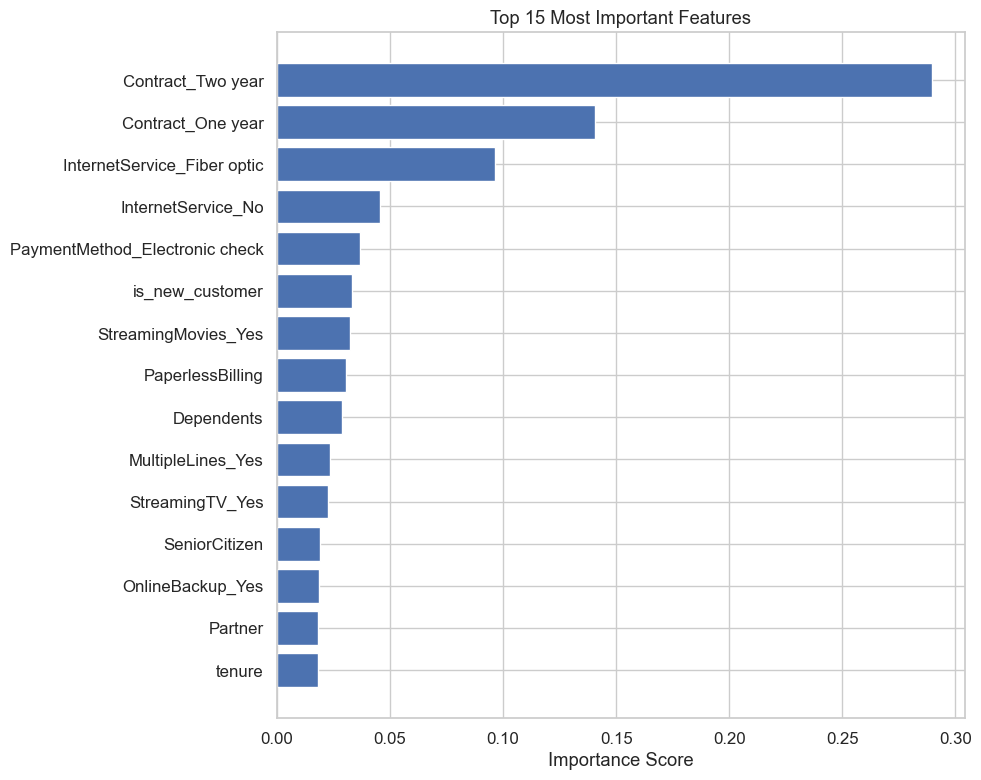

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names
ohe_features = preprocessor.named_transformers_['multi_cat']\
                            .get_feature_names_out(multi_cat)

all_features = binary_cols + list(ohe_features) + numerical_cols

# Get importances
feat_imp = pd.DataFrame({
    'feature':    all_features,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(10))  # top 10

# Plot
plt.figure(figsize=(10,8))
plt.barh(feat_imp['feature'][:15], feat_imp['importance'][:15])
plt.gca().invert_yaxis()
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


In [39]:
#cv fold test
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
from sklearn.pipeline import Pipeline

# Use stratified kfold — maintains class ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Encode full y first
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Run CV on RAW data — pipeline handles preprocessing internally
# We need to build a full pipeline including model for this

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_xgb)
])

# Score across multiple metrics
for metric in ['f1', 'recall', 'precision', 'accuracy']:
    scores = cross_val_score(
        full_pipeline, X, y_encoded,
        cv=cv,
        scoring=metric,
        n_jobs=-1
    )
    print(f"{metric:12} → mean: {scores.mean():.3f}  "
          f"std: {scores.std():.3f}  "
          f"per fold: {[round(s,2) for s in scores]}")




f1           → mean: 0.580  std: 0.024  per fold: [np.float64(0.6), np.float64(0.59), np.float64(0.6), np.float64(0.54), np.float64(0.58)]
recall       → mean: 0.527  std: 0.029  per fold: [np.float64(0.55), np.float64(0.56), np.float64(0.54), np.float64(0.47), np.float64(0.52)]
precision    → mean: 0.646  std: 0.022  per fold: [np.float64(0.67), np.float64(0.63), np.float64(0.66), np.float64(0.61), np.float64(0.65)]
accuracy     → mean: 0.798  std: 0.009  per fold: [np.float64(0.81), np.float64(0.79), np.float64(0.81), np.float64(0.78), np.float64(0.8)]


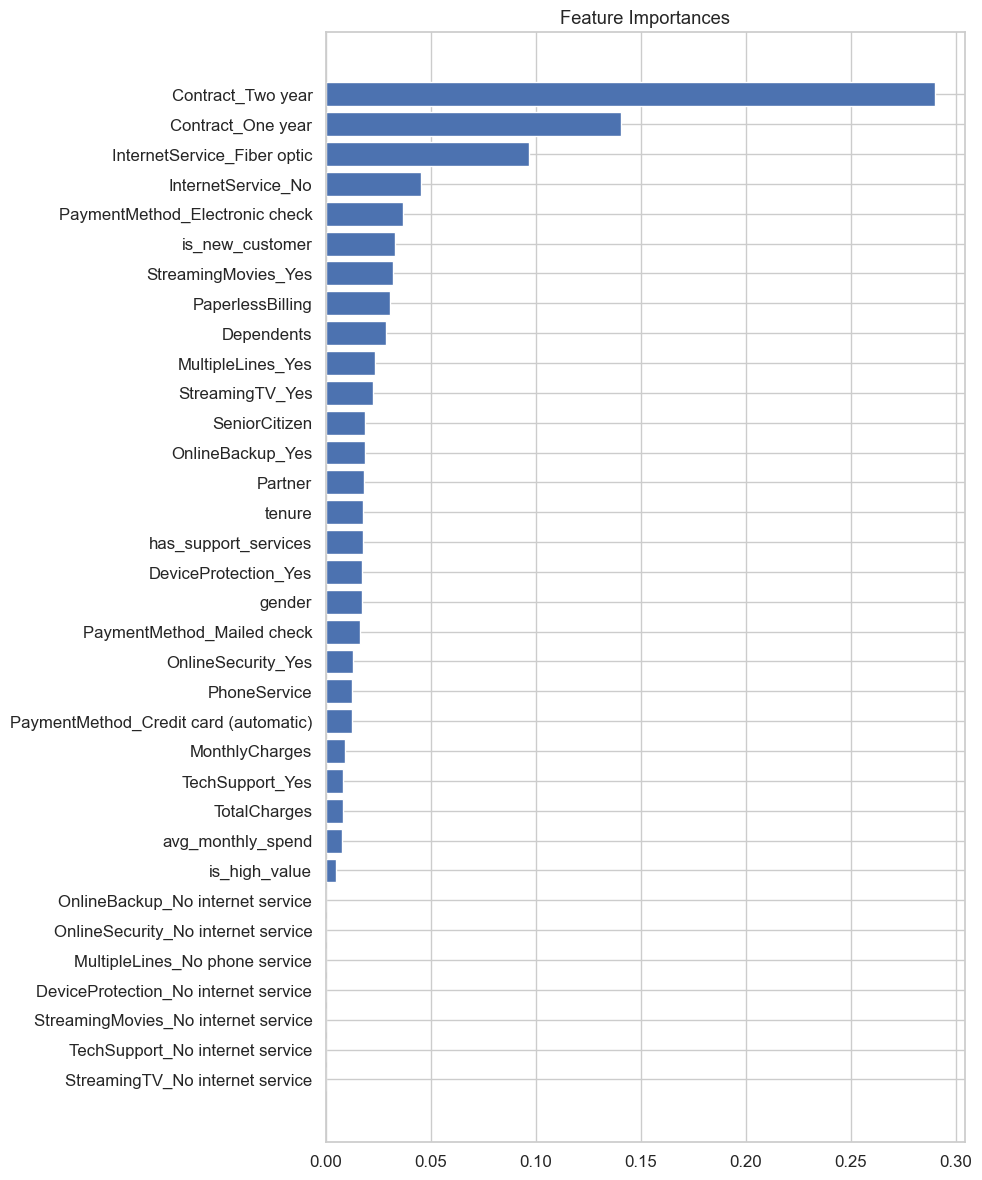

In [40]:
# XGBoost has built in feature importance
# which gives similar insights without SHAP

import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature':    all_features,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.tight_layout()
plt.show()


 99%|===================| 1393/1409 [00:24<00:00]        

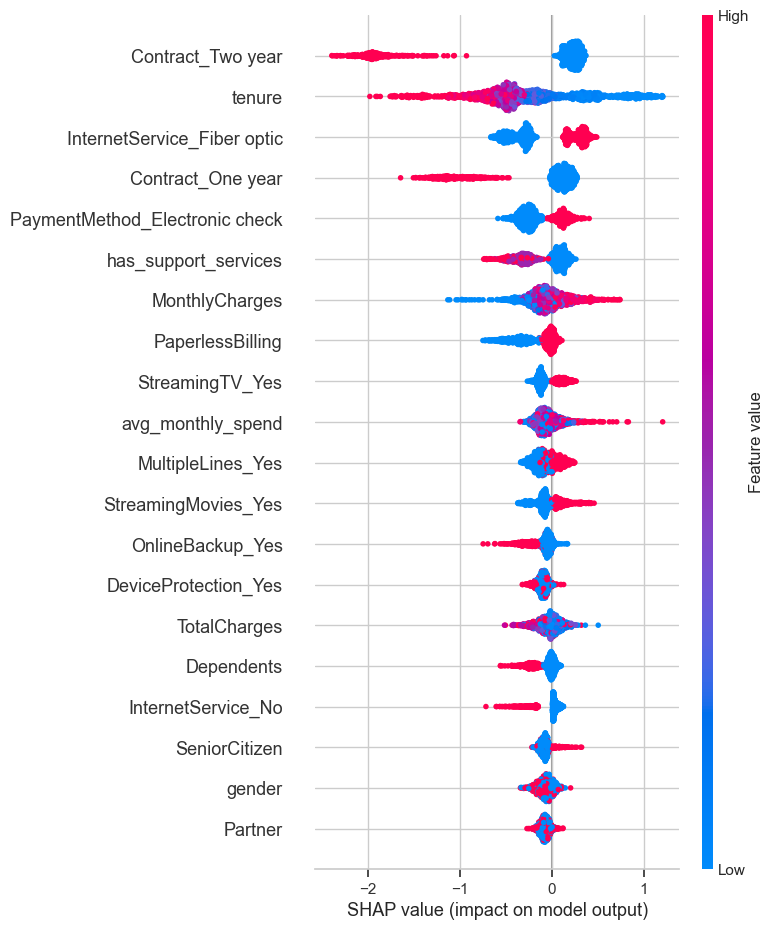

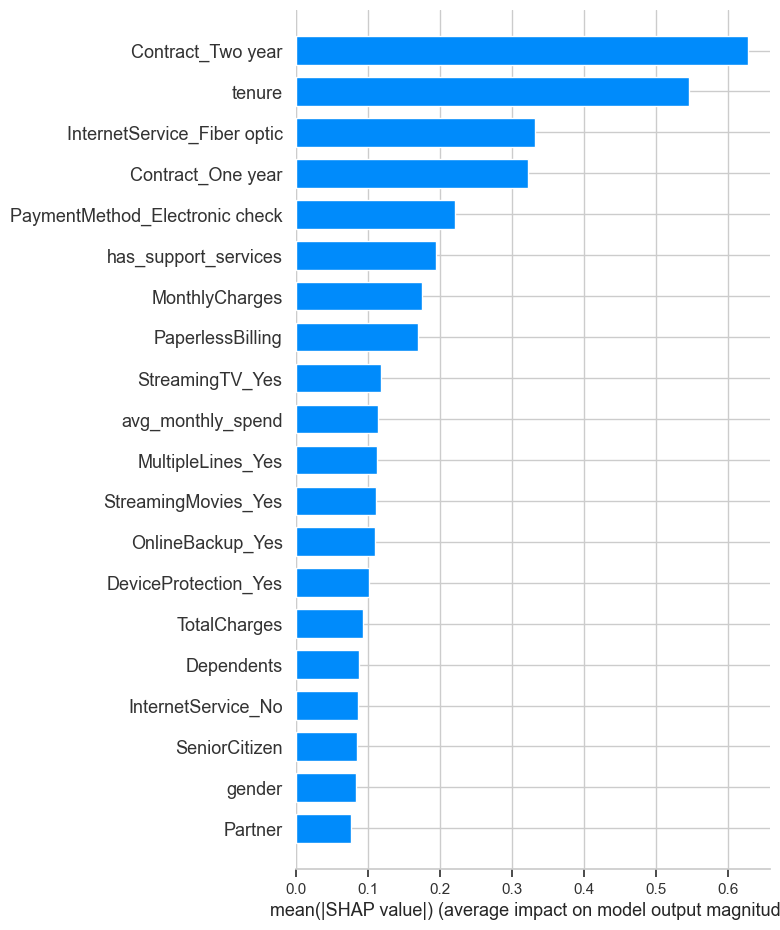

In [41]:
import shap
import numpy as np
import matplotlib.pyplot as plt

X_test_array = np.array(X_test_transformed, dtype=np.float32)
X_train_array = np.array(X_train_smote, dtype=np.float32)

explainer = shap.TreeExplainer(
    best_xgb,
    data=X_train_array,
    feature_perturbation='interventional'
)

shap_values = explainer.shap_values(X_test_array, check_additivity=False)

# Feature names
ohe_features = preprocessor.named_transformers_['multi_cat']\
                            .get_feature_names_out(multi_cat)
all_features = binary_cols + list(ohe_features) + numerical_cols

# Plot 1: Overall summary
shap.summary_plot(shap_values,
                  X_test_array,
                  feature_names=all_features)

# Plot 2: Bar chart version
shap.summary_plot(shap_values,
                  X_test_array,
                  feature_names=all_features,
                  plot_type='bar')

In [42]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

#Final model

# Step 1: Encode y_train and y_test
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train) 
y_test_encoded  = le.transform(y_test)

# Step 2: Build full pipeline
full_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('model',        XGBClassifier(
                        **search.best_params_,
                        random_state=42,
                        n_jobs=-1
                    ))
])

# Step 3: Fit on RAW X_train — pipeline handles everything 
full_pipeline.fit(X_train, y_train_encoded)

# Step 4: Predict on RAW X_test 
y_pred_pipe = full_pipeline.predict(X_test)

print(classification_report(y_test_encoded, y_pred_pipe))


              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.62      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409



In [43]:
import joblib
import os

artifacts = {
    'pipeline':      full_pipeline,   # preprocessor + smote + model
    'label_encoder': le,              # to decode 0/1 → Yes/No
    'feature_names': all_features     # for reference
}

# Step 1: Save
joblib.dump(artifacts, 'churn_pipeline.joblib')
print("Saved")
print("Size:", round(os.path.getsize('churn_pipeline.joblib')/1024), "KB")

# Step 2: Load into DIFFERENT variable to verify
loaded_artifacts = joblib.load('churn_pipeline.joblib')

# Step 3: Verify contents match
print("\nKeys match:", 
      set(artifacts.keys()) == set(loaded_artifacts.keys()))  # 

# Step 4: Use loaded version
pipeline = loaded_artifacts['pipeline']
le       = loaded_artifacts['label_encoder']
print("Pipeline steps:", [step[0] for step in pipeline.steps])


Saved
Size: 991 KB

Keys match: True
Pipeline steps: ['preprocessor', 'smote', 'model']


In [44]:
# Extract everything from loaded artifacts
pipeline  = loaded_artifacts['pipeline']
le_loaded = loaded_artifacts['label_encoder']

# Test single customer
sample = X_test.iloc[[0]]
pred   = pipeline.predict(sample)
proba  = pipeline.predict_proba(sample)[:,1]

print("Prediction:", le_loaded.inverse_transform(pred)[0])
print("Churn probability:", round(proba[0] * 100, 1), "%")

# Test 5 customers
X_sample      = X_test.iloc[:5]
y_actual      = y_test.iloc[:5].values
y_predicted   = le_loaded.inverse_transform(pipeline.predict(X_sample))
y_proba       = (pipeline.predict_proba(X_sample)[:,1] * 100).round(1)

# Build results dataframe
results = pd.DataFrame({
    'actual':      y_actual,
    'predicted':   y_predicted,
    'churn_prob%': y_proba,
    'correct':     y_actual == y_predicted
})
print(results)


Prediction: No
Churn probability: 0.9 %
  actual predicted  churn_prob%  correct
0     No        No     0.900000     True
1     No       Yes    89.199997    False
2     No        No     8.400000     True
3     No        No    28.400000     True
4     No        No     0.500000     True
